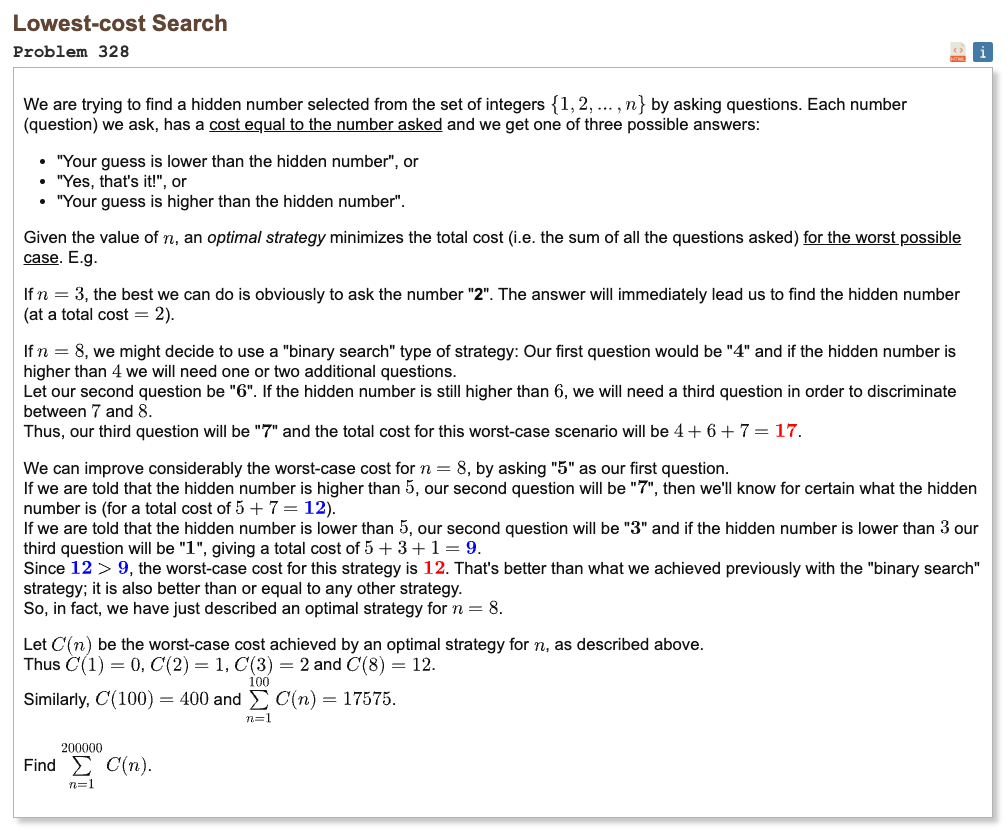

## Initial approach

* use dynamic programming for the optimal worst-case cost
* the first guess is usually close to the upper end
* the right side can be evaluated with a compact complete-tree cost formula
* store previous optimal costs and reuse them
* test only a small set of candidate first guesses
* verify the given values before solving the full limit
* no external library is used

In [1]:
def compute_costs(limit):
    powers = []
    x = 1

    while x < 400000:
        powers.append(x)
        x = x * 2 + 1

    cache = {}

    def lower_bound(arr, value):
        lo = 0
        hi = len(arr)

        while lo < hi:
            mid = (lo + hi) // 2

            if arr[mid] < value:
                lo = mid + 1
            else:
                hi = mid

        return lo

    def complete_coeff(length):
        if length in cache:
            return cache[length]

        if length <= 0:
            return (0, 0)

        if length == 1:
            return (1, 0)

        if length == 2:
            return (1, 1)

        idx = lower_bound(powers, length)
        t = powers[idx - 1]
        d = min(t, length - (t - 1) // 2)

        left_len = d - 1
        right_len = length - d - 1

        m1, c1 = complete_coeff(left_len)
        m2, c2 = complete_coeff(right_len)

        right_const = c2 + m2 * (d + 1)

        if m1 > m2:
            m, c = m1, c1
        elif m2 > m1:
            m, c = m2, right_const
        elif c1 >= right_const:
            m, c = m1, c1
        else:
            m, c = m2, right_const

        result = (m + 1, d + c)
        cache[length] = result

        return result

    def complete_cost(lo, hi):
        length = hi - lo
        m, c = complete_coeff(length)
        return m * lo + c

    costs = [0] * (limit + 1)
    seeds = {1: 0, 2: 1, 3: 2, 4: 4, 5: 6, 6: 8}

    for n, value in seeds.items():
        if n <= limit:
            costs[n] = value

    if limit <= 6:
        return costs, sum(costs[1:limit + 1])

    dist = 3
    deltas = [0]
    p = 4

    while p <= 131072:
        deltas.append(p)
        p *= 2

    window = 2
    total = sum(costs[1:7])

    for n in range(7, limit + 1):
        if dist > 4 ** window:
            window += 1

        best_cost = None
        best_dist = None

        for delta in deltas[:window]:
            k = n - dist - delta

            if not (0 < k < n):
                continue

            left = costs[k - 1]
            right = 0 if k == n else complete_cost(k + 1, n)
            cost = k + max(left, right)

            if best_cost is None or cost < best_cost:
                best_cost = cost
                best_dist = dist + delta

        costs[n] = best_cost
        dist = best_dist
        total += best_cost

    return costs, total

def solve(limit):
    costs, total = compute_costs(limit)
    return costs, total

costs_100, total_100 = solve(100)

assert costs_100[1] == 0
assert costs_100[2] == 1
assert costs_100[3] == 2
assert costs_100[8] == 12
assert costs_100[100] == 400
assert total_100 == 17575

In [2]:
%%time
costs, result = solve(200000)
print("Result:", result)

Result: 260511850222
CPU times: user 411 ms, sys: 4.46 ms, total: 416 ms
Wall time: 415 ms
